# Population-model training analysis — full post-adaptation sweep

## 1. GENERAL ANALYSIS - WITHOUT ADAPTATION

### 1.1. Auxiliary functions

In [1]:
import sys, pathlib, warnings, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon
from IPython.display import display, Markdown

# The notebook lives in src/ProVoice/training_analysis/; walk up to find src/.
_SRC = pathlib.Path.cwd()
for _ in range(6):
    if (_SRC / "ProVoice").is_dir():
        break
    _SRC = _SRC.parent
sys.path.insert(0, str(_SRC))

# Imported, not re-implemented: anything recomputed from the curves must use the
# SAME smoothing the sweep used, or it answers a different question.
from ProVoice.training_scripts.sweep_population_hparams import smooth, SMOOTH_WINDOW
# The selection estimator itself, so this notebook cannot rank configurations
# by a different rule than the sweep used. See docs/selection_rule.md.
from ProVoice.training_scripts.blocked_stats import blocked_effects

%matplotlib inline
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------- configuration
# BOTH sweep directories. The extension run covers a different corner of the
# (dropout, lr) grid, and w20's rows are split across the two, so every loader below
# reads from all of them and de-duplicates. The 12 cells the two share are bit
# identical, which is asserted rather than assumed when the tables are built.
BASES = [pathlib.Path("../../../results/pop_adapt_full"),
         pathlib.Path("../../../results/pop_adapt_full_ext")]
BASE = BASES[0]        # kept for any path printed for provenance


def stage_dirs(name: str):
    """Every directory holding rows for this stage, in priority order."""
    return [b / name for b in BASES if (b / name).exists()]
MIN_SELECT_EPOCH = 3      # must match the value the sweep ran with
LOA = [0, 1, 2, 3, 4]

STAGES = [
    ("corn_w10", "1. Full grid — soft-CORN, 10 s window"),
    ("corn_w20", "2. Full grid — soft-CORN, 20 s window"),
]
for b in BASES:
    print(f"BASE = {b.resolve()}  {'(found)' if b.exists() else '(MISSING)'}")
for name, _ in STAGES:
    parts = []
    for d in stage_dirs(name):
        f = d / "sweep_results.csv"
        parts.append(f"{d.parent.name}:{(sum(1 for _ in f.open()) - 1) if f.exists() else 0}")
    print(f"  {name:<10} " + ("  ".join(parts) if parts else "MISSING"))

BASE = C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\results\pop_adapt_full  (found)
BASE = C:\DATA\UCL\Asignaturas\TFM\MarkColley_Mercedes\ProActivity_Personalization\results\pop_adapt_full_ext  (found)
  corn_w10   pop_adapt_full:228
  corn_w20   pop_adapt_full:144  pop_adapt_full_ext:96


In [2]:
# ------------------------------------------------------------------- loading

_OVERLAP_REPORTED = set()


def load_stage(name: str) -> pd.DataFrame:
    """One stage's sweep_results.csv, or an empty frame if it has not run."""
    frames = []
    for d in stage_dirs(name):
        f = d / "sweep_results.csv"
        if f.exists():
            frames.append(pd.read_csv(f).assign(_src=d.parent.name))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    # A run is identified by (config, fold, seed). Where the two sweeps overlap the
    # rows are duplicates of the same computation -- verified bit-identical -- so one
    # is dropped. Keeping both would double-weight those cells inside every block.
    RUN_KEY = ["dropout", "lr", "embed_fcd", "fold", "seed"]
    if all(k in df.columns for k in RUN_KEY):
        dup = df.duplicated(subset=RUN_KEY, keep=False)
        # load_stage is called many times; report the overlap ONCE per stage so the
        # notebook output stays readable but the check is still visible.
        if dup.any() and name not in _OVERLAP_REPORTED:
            _OVERLAP_REPORTED.add(name)
            v = (df[dup].groupby(RUN_KEY).smoothed_best_adapt_mae
                 .agg(lambda x: x.max() - x.min()).abs().max())
            print(f"[{name}] {dup.sum()} overlapping row(s) across sweeps; "
                  f"max disagreement {v:.2e}" + ("  -> identical" if v == 0 else
                                                 "  -> DIFFER, inspect before trusting"))
        df = df.drop_duplicates(subset=RUN_KEY, keep="first").reset_index(drop=True)
    # window/loss are constant within a stage, so the configuration IS (dropout, lr).
    # embed_fcd is now an AXIS, not a constant, so it belongs in the config key:
    # averaging an augmented head together with a plain one would hide exactly the
    # comparison section C exists to make.
    df["config"] = ("drop=" + df["dropout"].astype(str)
                    + " lr=" + df["lr"].map(lambda x: f"{x:g}")
                    + df.get("embed_fcd", 0).map(lambda v: " +fcd" if int(v) else ""))
    return df


def load_curves(name: str) -> pd.DataFrame:
    """Every per-epoch curve for a stage, tagged by its filename."""
    out, seen = [], set()
    for d in [x / "runs" for x in stage_dirs(name)]:
        if not d.exists():
            continue
        for f in sorted(d.glob("metrics_*.csv")):
            tag = f.stem[len("metrics_"):]
            if tag in seen:           # same run present in both sweeps
                continue
            seen.add(tag)
            try:
                c = pd.read_csv(f)
            except Exception:
                continue
            if c.empty:
                continue
            c["tag"] = tag
            out.append(c)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


def _config_from_tag(tag: str):
    """(config label, dropout, lr, fold) from a run tag `d0.15_lr0.002_f001-005_s0_w10_corn`."""
    try:
        drop = float(tag.split("_lr")[0][1:])
        rest = tag.split("_lr")[1]
        lr = float(rest.split("_f")[0])
        fold = rest.split("_f")[1].split("_s")[0].replace("-", "|")
        # Run tags gain a trailing "_fcd" for the augmented arm. Folded into the
        # LABEL rather than returned separately, so the arity stays 4 and every
        # existing caller keeps working.
        suffix = " +fcd" if tag.endswith("_fcd") else ""
        return f"drop={drop} lr={lr:g}{suffix}", drop, lr, fold
    except Exception:
        return "?", np.nan, np.nan, "?"


def per_run_curves(name: str, min_select_epoch: int = MIN_SELECT_EPOCH) -> pd.DataFrame:
    """One row per RUN, derived from its retained per-epoch curve.

    The shared source for the early-win and init-vs-best tables — both need the
    curve, not the summary CSV, because the summary only records the FLOORED
    selection and never records the untrained init.
    """
    curves = load_curves(name)
    if curves.empty:
        return pd.DataFrame()
    rows = []
    for tag, c in curves.groupby("tag"):
        c = c.sort_values("epoch")
        mae = c["set_mae"].to_numpy(dtype=float)
        if len(mae) == 0:
            continue
        sm = smooth(mae, SMOOTH_WINDOW)
        j_free = int(np.argmin(sm))                        # no floor
        lo = min(int(min_select_epoch), len(sm) - 1)
        j_sel = lo + int(np.argmin(sm[lo:]))               # as the sweep selects
        cfg, drop, lr, fold = _config_from_tag(tag)

        def col(nm, default=np.nan):
            return float(c[nm].iloc[0]) if nm in c.columns and pd.notna(c[nm].iloc[0]) else default

        rows.append({
            "tag": tag, "config": cfg, "dropout": drop, "lr": lr, "val_pids": fold,
            "epochs_run": len(mae),
            "epoch_unfloored": int(c["epoch"].iloc[j_free]),
            "epoch_selected": int(c["epoch"].iloc[j_sel]),
            "mae_unfloored": float(sm[j_free]),
            "mae_selected": float(sm[j_sel]),
            "acc_selected": float(c["set_acc"].iloc[j_sel]),
            "init_mae": col("init_set_mae"), "init_acc": col("init_set_acc"),
            "const_mae": col("const_set_mae"), "const_acc": col("const_set_acc"),
        })
    return pd.DataFrame(rows)


def _fmt(df: pd.DataFrame, cols) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df:
            df[c] = df[c].astype(float).round(3)
    return df

In [3]:

def table_per_config(df: pd.DataFrame) -> pd.DataFrame:
    """set-MAE / set-accuracy per configuration, averaged over folds and seeds.

    `set_mae` is `smoothed_best_set_mae` — what the sweep RANKS on — not the raw
    per-epoch minimum, which is optimistically biased by minimising over ~100
    noisy epochs. `mae_raw` keeps that minimum alongside so the gap is visible.

    `vs_const` is the number to read: negative beats a constant prediction,
    positive does not.
    """
    if df.empty:
        return pd.DataFrame()
    g = df.groupby("config", as_index=False).agg(
        n_runs=("seed", "size"),
        set_mae=("smoothed_best_set_mae", "mean"),
        mae_sd=("smoothed_best_set_mae", "std"),
        mae_raw=("best_set_mae", "mean"),
        set_acc=("set_acc_at_best", "mean"),
        acc_sd=("set_acc_at_best", "std"),
        qwk=("qwk_at_best", "mean"),
        const_mae=("const_set_mae", "mean"),
        const_acc=("const_set_acc", "mean"),
        E_star=("best_epoch_1se", "median"),
    )
    g["mae_se"] = g["mae_sd"] / np.sqrt(g["n_runs"].clip(lower=1))
    g["vs_const"] = g["set_mae"] - g["const_mae"]
    g["beats_const"] = g["vs_const"] < 0
    cols = ["config", "n_runs", "set_mae", "mae_sd", "mae_se", "mae_raw",
            "set_acc", "acc_sd", "qwk", "const_mae", "const_acc",
            "vs_const", "beats_const", "E_star"]
    return _fmt(g[cols].sort_values("set_mae").reset_index(drop=True),
                ["set_mae", "mae_sd", "mae_se", "mae_raw", "set_acc", "acc_sd",
                 "qwk", "const_mae", "const_acc", "vs_const"])


def table_per_config_fold(df: pd.DataFrame) -> pd.DataFrame:
    """The same metrics broken out by configuration x validation fold.

    Where fold heterogeneity becomes visible: constant floors range ~0.54 to ~1.47
    across folds, so a configuration's mean hides which folds it actually failed on.
    """
    if df.empty:
        return pd.DataFrame()
    g = df.groupby(["config", "val_pids"], as_index=False).agg(
        n_seeds=("seed", "size"),
        set_mae=("smoothed_best_set_mae", "mean"),
        mae_sd=("smoothed_best_set_mae", "std"),
        set_acc=("set_acc_at_best", "mean"),
        acc_sd=("set_acc_at_best", "std"),
        const_mae=("const_set_mae", "mean"),
        const_acc=("const_set_acc", "mean"),
        val_n=("val_n", "mean"),
        E_star=("best_epoch_1se", "median"),
    )
    g["vs_const"] = g["set_mae"] - g["const_mae"]
    g["beats_const"] = g["vs_const"] < 0
    return _fmt(g.sort_values(["config", "val_pids"]).reset_index(drop=True),
                ["set_mae", "mae_sd", "set_acc", "acc_sd", "const_mae",
                 "const_acc", "vs_const"])

In [4]:
# plots

def plot_val_curves(name: str, title: str):
    """Validation curves vs epoch — set-MAE (top row) and set-accuracy (bottom).

    **Left column** plots each metric MINUS that fold's own constant floor,
    averaged over folds and seeds, one line per configuration. Plotting raw
    values would be misleading: folds differ in difficulty by ~0.9 MAE, so an
    average across them mixes levels and the shape would be dominated by which
    folds a configuration happened to run. On these axes **y = 0 is the constant
    baseline**.

    **The two rows have OPPOSITE good directions** and the axis labels say so:
    for set-MAE lower is better, so below zero beats the floor; for
    set-accuracy higher is better, so above zero beats it. The floors are also
    two different predictors — the MAE-optimal constant and the
    accuracy-optimal constant are usually different LoAs (`const_loa_mae` vs
    `const_loa_acc`), which is why each row uses its own.

    **Right column** takes the best configuration and shows one raw line per
    fold, with that fold's floor as a matching dotted line. The spread between
    folds is the driver heterogeneity everything else here is about. Both rows
    use the SAME configuration — chosen on MAE, the design's selection metric —
    so the two views describe one model, not two.

    The dashed grey line is the untrained init; the vertical line is
    `--min-select-epoch`. A curve starting past the floor and moving away from
    it is a model whose held-out performance is degraded by training; a genuine
    interior optimum is one worth selecting an epoch from.
    """
    curves = load_curves(name)
    if curves.empty:
        print("(no per-epoch curves in runs/)")
        return
    need = {"const_set_mae", "const_set_acc", "set_acc"}
    if not need.issubset(curves.columns):
        print(f"(curves lack {sorted(need - set(curves.columns))} — re-run the sweep)")
        return
    meta = curves["tag"].map(_config_from_tag)
    curves = curves.assign(config=[m[0] for m in meta], val_pids=[m[3] for m in meta])
    curves["d_mae"] = curves["set_mae"] - curves["const_set_mae"]
    curves["d_acc"] = curves["set_acc"] - curves["const_set_acc"]

    # One configuration drives both right-hand panels: picked on MAE, because
    # that is what the sweep selects on. Accuracy is reported, never selected on.
    best = curves.groupby("config")["d_mae"].mean().idxmin()

    fig, axes = plt.subplots(2, 2, figsize=(13, 8.4))
    cmap = plt.get_cmap("tab10")

    rows = [
        # (row, delta col, raw col, floor col, ylabel, init col, better)
        (0, "d_mae", "set_mae", "const_set_mae",
         "set-MAE minus fold's floor", "init_set_mae", "lower is better"),
        (1, "d_acc", "set_acc", "const_set_acc",
         "set-accuracy minus fold's floor", "init_set_acc", "higher is better"),
    ]
    for r, dcol, raw, floor, ylab, initcol, better in rows:
        axL, axR = axes[r][0], axes[r][1]

        for cfg, c in curves.groupby("config"):
            s = c.groupby("epoch")[dcol].mean()
            axL.plot(s.index, s.values, lw=1.6, label=cfg)
        axL.axhline(0, color="crimson", lw=1.4, label="constant floor (y=0)")
        if initcol in curves.columns and curves[initcol].notna().any():
            init_d = float((curves[initcol] - curves[floor]).mean())
            axL.axhline(init_d, color="0.45", ls="--", lw=1.2,
                        label=f"untrained init ({init_d:+.2f})")
        axL.axvline(MIN_SELECT_EPOCH, color="0.7", ls=":", lw=1.2)
        axL.set_xlabel("epoch")
        axL.set_ylabel(f"{ylab}\n({better})", fontsize=9)
        axL.set_title(f"vs constant floor — {better} (mean over folds & seeds)", fontsize=10)
        axL.grid(alpha=0.3)
        axL.legend(fontsize=7)

        sub = curves[curves["config"] == best]
        for i, (fold, c) in enumerate(sub.groupby("val_pids")):
            col = cmap(i % 10)
            s = c.groupby("epoch")[raw].mean()
            axR.plot(s.index, s.values, lw=1.5, color=col, label=f"val={fold}")
            axR.axhline(float(c[floor].iloc[0]), color=col, ls=":", lw=1.0)
        axR.axvline(MIN_SELECT_EPOCH, color="0.7", ls=":", lw=1.2)
        axR.set_xlabel("epoch")
        axR.set_ylabel(f"{raw} (raw)\n({better})", fontsize=9)
        axR.set_title(f"per fold — {best}  (dotted = that fold's floor)", fontsize=10)
        axR.grid(alpha=0.3)
        axR.legend(fontsize=7)

    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()



In [5]:
def report_stage(name: str, title: str):
    """Everything for one stage, identical order and format across all four."""
    df = load_stage(name)
    display(Markdown(f"### {title}"))
    if df.empty:
        print(f"(stage '{name}' has not run — no sweep_results.csv)")
        return
    w = df["window_seconds"].iloc[0] if "window_seconds" in df else "?"
    lo = df["loss"].iloc[0] if "loss" in df else "?"
    print(f"{len(df)} runs | loss={lo} | window={w}s | "
          f"{df['config'].nunique()} configuration(s) | "
          f"{df['val_pids'].nunique()} fold(s) | {df['seed'].nunique()} seed(s)")
    pr = per_run_curves(name)

    display(Markdown("**Table 1 — per configuration** (mean over folds and seeds)"))
    display(table_per_config(df))

    display(Markdown("**Table 2 — per configuration x validation fold** (mean over seeds)"))
    display(table_per_config_fold(df))

    plot_val_curves(name, f"{title} — validation curves")


---

### 1.2. soft-CORN 20 s window

[corn_w20] 24 overlapping row(s) across sweeps; max disagreement 0.00e+00  -> identical


### 1. Full grid — soft-CORN, 20 s window

228 runs | loss=corn | window=20.0s | 19 configuration(s) | 6 fold(s) | 2 seed(s)


**Table 1 — per configuration** (mean over folds and seeds)

,config,n_runs,set_mae,mae_sd,mae_se,mae_raw,set_acc,acc_sd,qwk,const_mae,const_acc,vs_const,beats_const,E_star
0,drop=0.2 lr=0.005 +fcd,12,1.339,0.385,0.111,1.177,0.349,0.094,0.067,1.161,0.402,0.179,False,6.5
1,drop=0.2 lr=0.01 +fcd,12,1.395,0.430,0.124,1.237,0.365,0.094,0.011,1.161,0.402,0.234,False,6.5
2,drop=0.2 lr=0.003 +fcd,12,1.492,0.188,0.054,1.278,0.312,0.090,0.072,1.161,0.402,0.331,False,9.0
3,drop=0.2 lr=0.002 +fcd,12,1.497,0.189,0.055,1.267,0.304,0.076,0.065,1.161,0.402,0.336,False,6.0
4,drop=0.1 lr=0.001,12,1.503,0.167,0.048,1.206,0.297,0.061,0.050,1.161,0.402,0.342,False,8.5
5,drop=0.1 lr=0.002 +fcd,12,1.504,0.173,0.050,1.279,0.295,0.054,0.068,1.161,0.402,0.343,False,5.5
6,drop=0.15 lr=0.001 +fcd,12,1.506,0.175,0.051,1.215,0.291,0.056,0.053,1.161,0.402,0.345,False,6.5
7,drop=0.2 lr=0.002,12,1.510,0.182,0.052,1.243,0.310,0.061,0.023,1.161,0.402,0.349,False,6.5
8,drop=0.15 lr=0.002 +fcd,12,1.511,0.164,0.047,1.253,0.316,0.057,0.059,1.161,0.402,0.350,False,5.0
9,drop=0.2 lr=0.001 +fcd,12,1.513,0.198,0.057,1.240,0.305,0.058,0.058,1.161,0.402,0.353,False,5.5


**Table 2 — per configuration x validation fold** (mean over seeds)

,config,val_pids,n_seeds,set_mae,mae_sd,set_acc,acc_sd,const_mae,const_acc,val_n,E_star,vs_const,beats_const
0,drop=0.1 lr=0.001,001|005,2,1.596,0.025,0.301,0.014,1.209,0.377,244.0,20.5,0.387,False
1,drop=0.1 lr=0.001,002|006,2,1.612,0.024,0.231,0.131,1.124,0.462,210.0,7.5,0.489,False
2,drop=0.1 lr=0.001,003|007,2,1.510,0.130,0.298,0.093,1.422,0.322,258.0,14.5,0.088,False
3,drop=0.1 lr=0.001,004|008,2,1.354,0.073,0.304,0.018,0.538,0.471,240.0,7.5,0.817,False
4,drop=0.1 lr=0.001,009|011,2,1.259,0.073,0.346,0.008,1.468,0.368,250.0,6.0,-0.209,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,drop=0.3 lr=0.003 +fcd,002|006,2,1.549,0.044,0.293,0.071,1.124,0.462,210.0,6.0,0.425,False
110,drop=0.3 lr=0.003 +fcd,003|007,2,1.695,0.074,0.229,0.049,1.422,0.322,258.0,3.0,0.272,False
111,drop=0.3 lr=0.003 +fcd,004|008,2,1.458,0.008,0.337,0.059,0.538,0.471,240.0,7.0,0.920,False
112,drop=0.3 lr=0.003 +fcd,009|011,2,1.152,0.113,0.388,0.006,1.468,0.368,250.0,4.5,-0.316,True


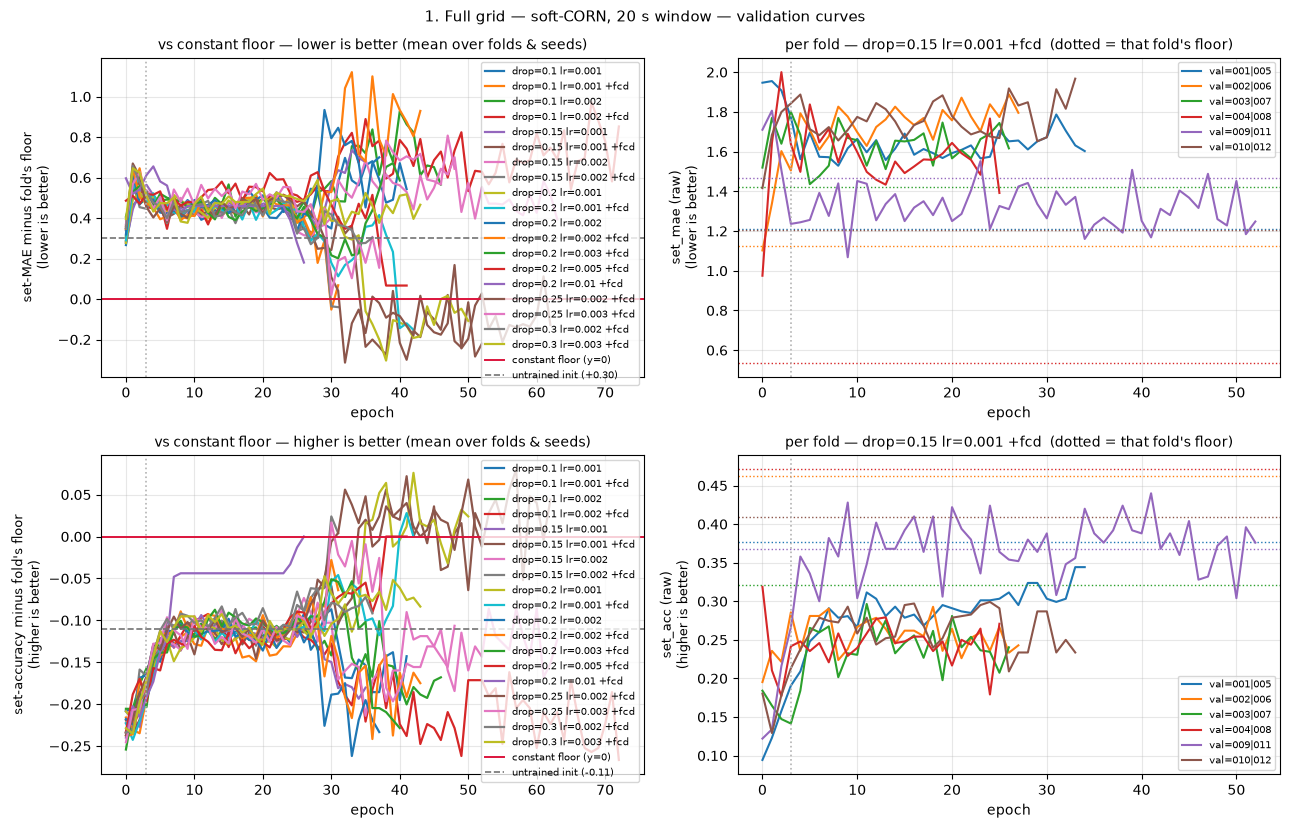

In [6]:
report_stage("corn_w20", "1. Full grid — soft-CORN, 20 s window")

---

### 1.3. soft-corn 10 s window

### 2. Full grid — soft-CORN, 10 s window

228 runs | loss=corn | window=10.0s | 19 configuration(s) | 6 fold(s) | 2 seed(s)


**Table 1 — per configuration** (mean over folds and seeds)

,config,n_runs,set_mae,mae_sd,mae_se,mae_raw,set_acc,acc_sd,qwk,const_mae,const_acc,vs_const,beats_const,E_star
0,drop=0.25 lr=0.01 +fcd,12,1.338,0.391,0.113,1.180,0.312,0.122,0.033,1.161,0.402,0.177,False,5.0
1,drop=0.2 lr=0.01 +fcd,12,1.368,0.435,0.125,1.207,0.306,0.150,-0.021,1.161,0.402,0.207,False,7.0
2,drop=0.25 lr=0.005 +fcd,12,1.443,0.311,0.090,1.268,0.331,0.117,0.075,1.161,0.402,0.282,False,8.0
3,drop=0.2 lr=0.005 +fcd,12,1.444,0.323,0.093,1.254,0.305,0.092,0.029,1.161,0.402,0.283,False,8.0
4,drop=0.15 lr=0.002 +fcd,12,1.503,0.176,0.051,1.273,0.293,0.059,0.041,1.161,0.402,0.342,False,8.5
5,drop=0.2 lr=0.001 +fcd,12,1.503,0.189,0.054,1.263,0.287,0.056,0.057,1.161,0.402,0.342,False,7.5
6,drop=0.15 lr=0.001 +fcd,12,1.511,0.188,0.054,1.256,0.287,0.047,0.047,1.161,0.402,0.351,False,5.5
7,drop=0.15 lr=0.001,12,1.514,0.185,0.053,1.227,0.295,0.073,0.003,1.161,0.402,0.353,False,7.0
8,drop=0.2 lr=0.002 +fcd,12,1.514,0.207,0.060,1.264,0.293,0.084,0.013,1.161,0.402,0.353,False,8.5
9,drop=0.2 lr=0.003 +fcd,12,1.521,0.188,0.054,1.298,0.314,0.060,0.083,1.161,0.402,0.360,False,7.0


**Table 2 — per configuration x validation fold** (mean over seeds)

,config,val_pids,n_seeds,set_mae,mae_sd,set_acc,acc_sd,const_mae,const_acc,val_n,E_star,vs_const,beats_const
0,drop=0.1 lr=0.001,001|005,2,1.635,0.041,0.289,0.020,1.209,0.377,244.0,11.5,0.426,False
1,drop=0.1 lr=0.001,002|006,2,1.599,0.007,0.252,0.074,1.124,0.462,210.0,3.0,0.475,False
2,drop=0.1 lr=0.001,003|007,2,1.624,0.081,0.223,0.036,1.422,0.322,258.0,9.0,0.202,False
3,drop=0.1 lr=0.001,004|008,2,1.362,0.115,0.294,0.044,0.538,0.471,240.0,10.0,0.824,False
4,drop=0.1 lr=0.001,009|011,2,1.201,0.096,0.404,0.051,1.468,0.368,250.0,9.5,-0.267,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,drop=0.25 lr=0.01 +fcd,002|006,2,1.233,0.041,0.340,0.172,1.124,0.462,210.0,6.0,0.109,False
110,drop=0.25 lr=0.01 +fcd,003|007,2,1.683,0.033,0.233,0.005,1.422,0.322,258.0,4.5,0.261,False
111,drop=0.25 lr=0.01 +fcd,004|008,2,0.604,0.000,0.471,0.000,0.538,0.471,240.0,10.0,0.067,False
112,drop=0.25 lr=0.01 +fcd,009|011,2,1.406,0.073,0.190,0.076,1.468,0.368,250.0,3.0,-0.062,True


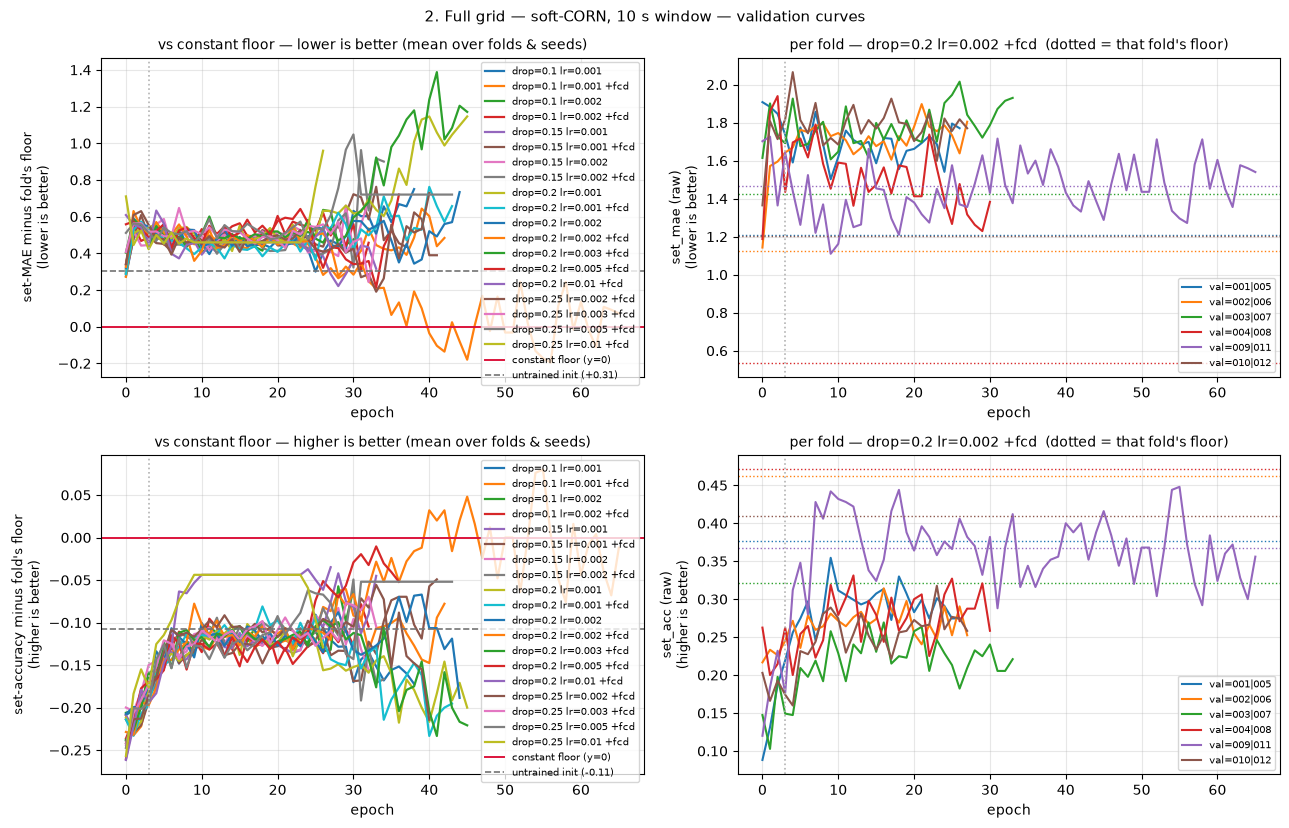

In [7]:
report_stage("corn_w10", "2. Full grid — soft-CORN, 10 s window")

---
## 2. Ranking on post-adaptation set-MAE

This is the number that chose the configuration. Two things about how it is computed:


In [8]:
def blocked_table(name: str, val: str = "smoothed_best_adapt_mae") -> pd.DataFrame:
    """Per-configuration blocked mean, with the raw mean beside it for contrast."""
    c = load_stage(name)
    if c.empty or val not in c.columns:
        return pd.DataFrame()
    b = blocked_effects([((r.dropout, r.lr, int(getattr(r, "embed_fcd", 0))),
                          (r.fold, r.seed), getattr(r, val)) for r in c.itertuples()])
    if b is None:
        print(f"[{name}] design too unbalanced to block — raw means only")
        return pd.DataFrame()
    t = pd.DataFrame([{"dropout": k[0], "lr": k[1], "fcd": k[2],
                       "set_MAE": v[0], "se": v[1], "n_blocks": v[2]}
                      for k, v in b.items()])
    agg = {"unadapted": ("smoothed_best_set_mae", "mean"),
           "E_1se": ("best_epoch_1se_adapt", "median"),
           "E_argmin": ("best_epoch_smoothed_adapt", "median"), "n": ("fold", "size")}
    raw = (c.groupby(["dropout", "lr", "embed_fcd"]).agg(**agg)
           .reset_index().rename(columns={"embed_fcd": "fcd"}))
    return t.merge(raw, on=["dropout", "lr", "fcd"]).sort_values("set_MAE")


for nm, title in STAGES:
    t = blocked_table(nm)
    if t.empty:
        continue
    display(Markdown(f"### {title} — ranked on POST-ADAPTATION set-MAE, fold-blocked"))
    display(t.round(4).reset_index(drop=True))
    best = t.iloc[0]
    band = t[t.set_MAE <= best.set_MAE + best.se]
    print(f"  minimum {best.set_MAE:.4f} +/- {best.se:.4f}; "
          f"{len(band)}/{len(t)} configuration(s) within 1 SE")
    # A winner on the boundary means the optimum may lie outside the grid, and the
    # sweep cannot tell you which. Worth catching here rather than in the write-up.
    edges = []
    if best.dropout == t.dropout.max(): edges.append(f"dropout={best.dropout:g} (max)")
    if best.dropout == t.dropout.min(): edges.append(f"dropout={best.dropout:g} (min)")
    if best.lr == t.lr.max(): edges.append(f"lr={best.lr:g} (max)")
    if best.lr == t.lr.min(): edges.append(f"lr={best.lr:g} (min)")
    if edges:
        print(f"  [GRID EDGE] the winner is at the boundary on: {', '.join(edges)} "
              f"-- extend the grid before treating this as an optimum.")
    print()

### 1. Full grid — soft-CORN, 10 s window — ranked on POST-ADAPTATION set-MAE, fold-blocked

,dropout,lr,fcd,set_MAE,se,n_blocks,unadapted,E_1se,E_argmin,n
0,0.20,0.005,1,0.8846,0.0167,12,1.4440,3.0,7.5,12
1,0.25,0.005,1,0.8946,0.0109,12,1.4434,6.0,8.5,12
2,0.25,0.003,1,0.8987,0.0088,12,1.5506,4.5,6.5,12
3,0.25,0.010,1,0.9215,0.0309,12,1.3380,3.0,3.5,12
4,0.20,0.003,1,0.9274,0.0140,12,1.5213,4.0,5.5,12
5,0.20,0.002,1,0.9338,0.0109,12,1.5143,6.0,9.0,12
6,0.15,0.002,1,0.9459,0.0113,12,1.5031,4.0,6.0,12
7,0.25,0.002,1,0.9485,0.0172,12,1.5259,4.0,7.0,12
8,0.10,0.002,1,0.9511,0.0128,12,1.5498,4.0,5.5,12
9,0.20,0.010,1,0.9604,0.0440,12,1.3675,3.0,4.5,12


  minimum 0.8846 +/- 0.0167; 3/19 configuration(s) within 1 SE



### 2. Full grid — soft-CORN, 20 s window — ranked on POST-ADAPTATION set-MAE, fold-blocked

,dropout,lr,fcd,set_MAE,se,n_blocks,unadapted,E_1se,E_argmin,n
0,0.20,0.005,1,0.8761,0.0145,12,1.3395,6.0,10.0,12
1,0.20,0.003,1,0.8999,0.0078,12,1.4921,5.0,8.5,12
2,0.25,0.003,1,0.9014,0.0136,12,1.5662,4.0,6.5,12
3,0.30,0.003,1,0.9016,0.0131,12,1.5224,4.0,6.5,12
4,0.20,0.002,1,0.9166,0.0162,12,1.4970,4.0,6.5,12
5,0.25,0.002,1,0.9332,0.0116,12,1.5147,4.0,6.5,12
6,0.30,0.002,1,0.9344,0.0151,12,1.5164,3.0,5.5,12
7,0.10,0.002,1,0.9348,0.0120,12,1.5037,4.5,7.0,12
8,0.20,0.001,1,0.9427,0.0131,12,1.5135,4.5,8.0,12
9,0.20,0.002,0,0.9530,0.0105,12,1.5098,4.0,6.5,12


  minimum 0.8761 +/- 0.0145; 1/19 configuration(s) within 1 SE



---
## C. The FCD-augmented head, paired

`--embed-fcd` widens the adapted head from `z_64` to `[z_64 | FCD_12]`, giving it
direct access to which in-vehicle task was prompted. The appended block is initialized
**and** population-model-anchored at zero, so K=0 reproduces the population head exactly.


corn_w10: FCD - plain = -0.0258 +/- 0.0059 (t=-4.34, n=72); FCD better in 48/72 cells
corn_w20: FCD - plain = -0.0239 +/- 0.0075 (t=-3.21, n=72); FCD better in 47/72 cells


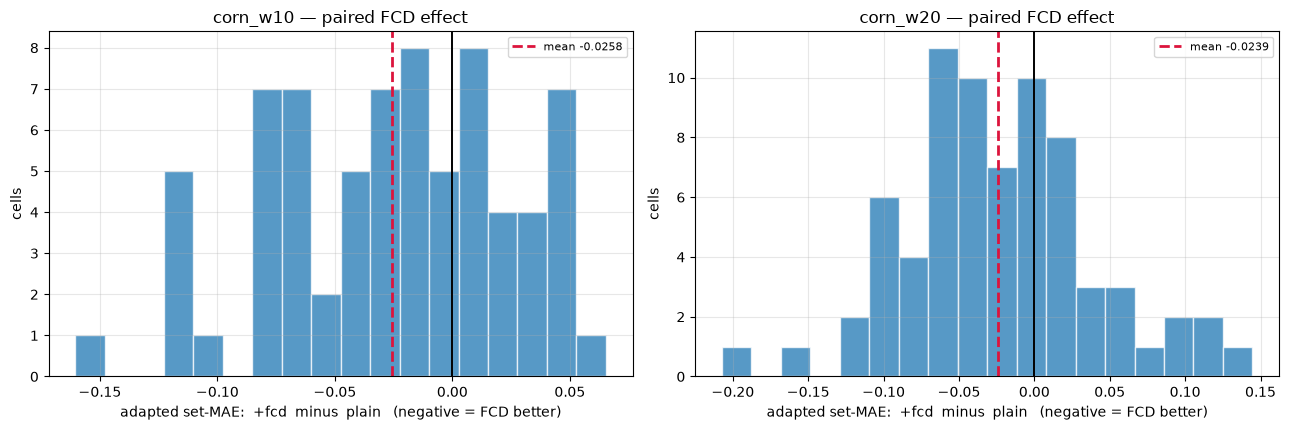

In [9]:
fig, axes = plt.subplots(1, len(STAGES), figsize=(6.5 * len(STAGES), 4.4), squeeze=False)
for ax, (nm, title) in zip(axes[0], STAGES):
    c = load_stage(nm)
    if c.empty or "embed_fcd" not in c.columns:
        ax.axis("off"); continue
    p = c.pivot_table(index=["dropout", "lr", "fold", "seed"], columns="embed_fcd",
                      values="smoothed_best_adapt_mae")
    if 0 not in p.columns or 1 not in p.columns:
        ax.axis("off"); continue
    d = (p[1] - p[0]).dropna()
    se = d.std(ddof=1) / np.sqrt(len(d))
    print(f"{nm}: FCD - plain = {d.mean():+.4f} +/- {se:.4f} "
          f"(t={d.mean()/se:+.2f}, n={len(d)}); FCD better in {(d < 0).sum()}/{len(d)} cells")
    ax.hist(d.values, bins=18, color="tab:blue", alpha=.75, edgecolor="w")
    ax.axvline(0, c="k", lw=1.4)
    ax.axvline(d.mean(), c="crimson", lw=2, ls="--", label=f"mean {d.mean():+.4f}")
    ax.set_xlabel("adapted set-MAE:  +fcd  minus  plain   (negative = FCD better)")
    ax.set_ylabel("cells"); ax.set_title(f"{nm} — paired FCD effect")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## E. 10 s vs 20 s window, paired

`window_seconds` is a **data contract**, not just a hyperparameter: it sets
`context_length` (100 vs 200), so the two are not interchangeable checkpoints and the
choice doubles backbone cost everywhere downstream — including the ANIL sweep, the
longest job in the pipeline.

Both stages ran the identical grid, folds and seeds, so every cell pairs exactly.

w20 - w10 = -0.0143 +/- 0.0066 (t=-2.16, n=204); w20 better in 118/204 cells


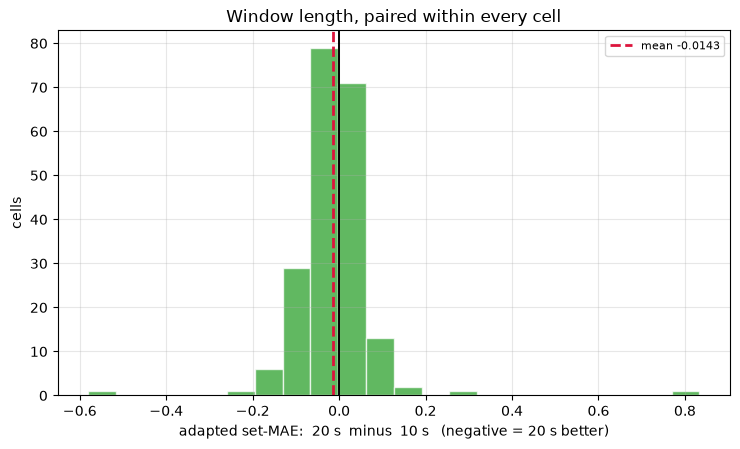

In [10]:
a, b = load_stage("corn_w10"), load_stage("corn_w20")
if a.empty or b.empty:
    print("both windows are needed for this section")
else:
    key = ["dropout", "lr", "embed_fcd", "fold", "seed"]
    m = a.merge(b, on=key, suffixes=("_10", "_20"))
    d = m.smoothed_best_adapt_mae_20 - m.smoothed_best_adapt_mae_10
    se = d.std(ddof=1) / np.sqrt(len(d))
    print(f"w20 - w10 = {d.mean():+.4f} +/- {se:.4f} (t={d.mean()/se:+.2f}, n={len(d)}); "
          f"w20 better in {(d < 0).sum()}/{len(d)} cells")
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    ax.hist(d.values, bins=22, color="tab:green", alpha=.75, edgecolor="w")
    ax.axvline(0, c="k", lw=1.4)
    ax.axvline(d.mean(), c="crimson", lw=2, ls="--", label=f"mean {d.mean():+.4f}")
    ax.set_xlabel("adapted set-MAE:  20 s  minus  10 s   (negative = 20 s better)")
    ax.set_ylabel("cells"); ax.set_title("Window length, paired within every cell")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print()


### E2. The two windows on one axis

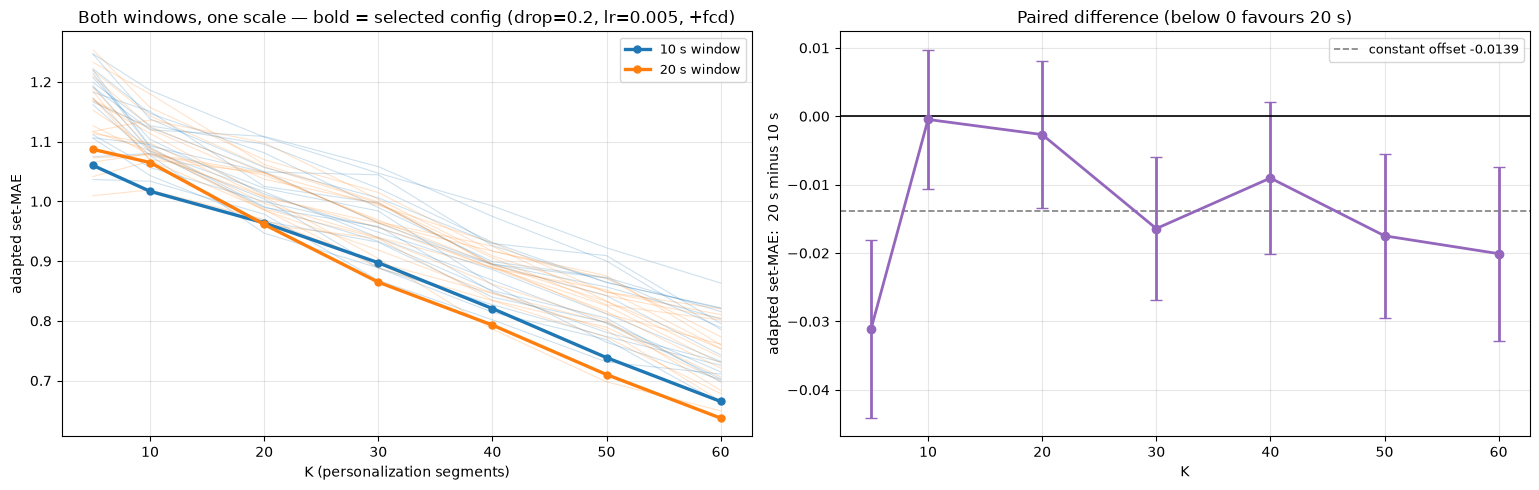

**Paired w20 − w10 at each K** (negative favours 20 s)

,w10,w20,delta,se,t
K,,,,,
5,1.1641,1.1423,-0.0311,0.0130,-2.3948
10,1.0973,1.0980,-0.0005,0.0102,-0.0458
20,1.0245,1.0202,-0.0027,0.0108,-0.2484
30,0.9643,0.9533,-0.0164,0.0104,-1.5759
40,0.8818,0.8765,-0.0090,0.0111,-0.8152
50,0.8247,0.8124,-0.0175,0.0120,-1.4577
60,0.7518,0.7340,-0.0201,0.0127,-1.5797


In [11]:
ADAPT_KS = [5, 10, 20, 30, 40, 50, 60]

a, b = load_stage("corn_w10"), load_stage("corn_w20")
if a.empty or b.empty:
    print("both windows are needed for this section")
else:
    key = ["dropout", "lr", "embed_fcd", "fold", "seed"]
    m = a.merge(b, on=key, suffixes=("_10", "_20"))
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 5))

    # ---- left: both windows on ONE axis, at the SELECTED configuration
    sel = blocked_table("corn_w10").iloc[0]
    msel = m[(m.dropout == sel.dropout) & (m.lr == sel.lr)
             & (m.embed_fcd == int(sel.fcd))]
    for tag, df_, c in (("10 s", a, "tab:blue"), ("20 s", b, "tab:orange")):
        w = df_[(df_.dropout == sel.dropout) & (df_.lr == sel.lr)
                & (df_.embed_fcd == int(sel.fcd))]
        axes[0].plot(ADAPT_KS, [w[f"adapt_mae_k{k}"].mean() for k in ADAPT_KS],
                     lw=2.4, marker="o", ms=5, color=c, label=f"{tag} window")
        # every other configuration, faint, so the spread between configurations can
        # be judged against the gap between windows
        for _, g in df_.groupby(["dropout", "lr", "embed_fcd"]):
            axes[0].plot(ADAPT_KS, [g[f"adapt_mae_k{k}"].mean() for k in ADAPT_KS],
                         lw=.8, color=c, alpha=.22, zorder=0)
    axes[0].set_xlabel("K (personalization segments)")
    axes[0].set_ylabel("adapted set-MAE")
    axes[0].set_title(f"Both windows, one scale — bold = selected config "
                      f"(drop={sel.dropout:g}, lr={sel.lr:g}"
                      f"{', +fcd' if int(sel.fcd) else ''})")
    axes[0].grid(alpha=.3); axes[0].legend(fontsize=9)

    # ---- right: the paired difference, which is the actual test
    means, ses = [], []
    for k in ADAPT_KS:
        d = (m[f"adapt_mae_k{k}_20"] - m[f"adapt_mae_k{k}_10"]).dropna()
        means.append(d.mean()); ses.append(d.std(ddof=1) / np.sqrt(len(d)))
    means, ses = np.array(means), np.array(ses)
    axes[1].errorbar(ADAPT_KS, means, yerr=ses, marker="o", lw=2, capsize=4,
                     color="tab:purple")
    axes[1].axhline(0, c="k", lw=1.2)
    axes[1].axhline(means.mean(), ls="--", c="0.5", lw=1.2,
                    label=f"constant offset {means.mean():+.4f}")
    axes[1].set_xlabel("K"); axes[1].set_ylabel("adapted set-MAE:  20 s minus 10 s")
    axes[1].set_title("Paired difference (below 0 favours 20 s)")
    axes[1].grid(alpha=.3); axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()

    t = pd.DataFrame({"K": ADAPT_KS, "w10": [a[f"adapt_mae_k{k}"].mean() for k in ADAPT_KS],
                      "w20": [b[f"adapt_mae_k{k}"].mean() for k in ADAPT_KS],
                      "delta": means, "se": ses, "t": means / ses})
    display(Markdown("**Paired w20 − w10 at each K** (negative favours 20 s)"))
    display(t.round(4).set_index("K"))

    # ---- the same difference at the SELECTED configuration alone.
    # Pooling over configurations estimates the WINDOW MAIN EFFECT and is what should
    # decide the window, since the window has no strong reason to interact with
    # dropout/lr and pooling buys ~4.5x precision. The single-config view is the
    # consistency check: if it disagrees in AGGREGATE, the pooling assumption is
    # wrong; if it merely scatters, that scatter is n=12 noise and any apparent
    # crossover in it is not evidence.
    sm, ss = [], []
    for k in ADAPT_KS:
        d = (msel[f"adapt_mae_k{k}_20"] - msel[f"adapt_mae_k{k}_10"]).dropna()
        sm.append(d.mean()); ss.append(d.std(ddof=1) / np.sqrt(len(d)))
    sm, ss = np.array(sm), np.array(ss)
    axes[1].errorbar(ADAPT_KS, sm, yerr=ss, marker="s", lw=1.6, capsize=3, ls="--",
                     color="tab:brown", alpha=.85,
                     label=f"selected config only (n={len(msel)})")
    axes[1].legend(fontsize=8)

    agg_all = (m.smoothed_best_adapt_mae_20 - m.smoothed_best_adapt_mae_10)
    agg_sel = (msel.smoothed_best_adapt_mae_20 - msel.smoothed_best_adapt_mae_10)
    cmp_ = pd.DataFrame([
        {"estimate": "all configurations", "delta": agg_all.mean(),
         "se": agg_all.std(ddof=1) / np.sqrt(len(agg_all)), "n": len(agg_all)},
        {"estimate": "selected config only", "delta": agg_sel.mean(),
         "se": agg_sel.std(ddof=1) / np.sqrt(len(agg_sel)), "n": len(agg_sel)}])
    cmp_["t"] = cmp_.delta / cmp_.se


### E3. Paired difference at the SELECTED configuration only

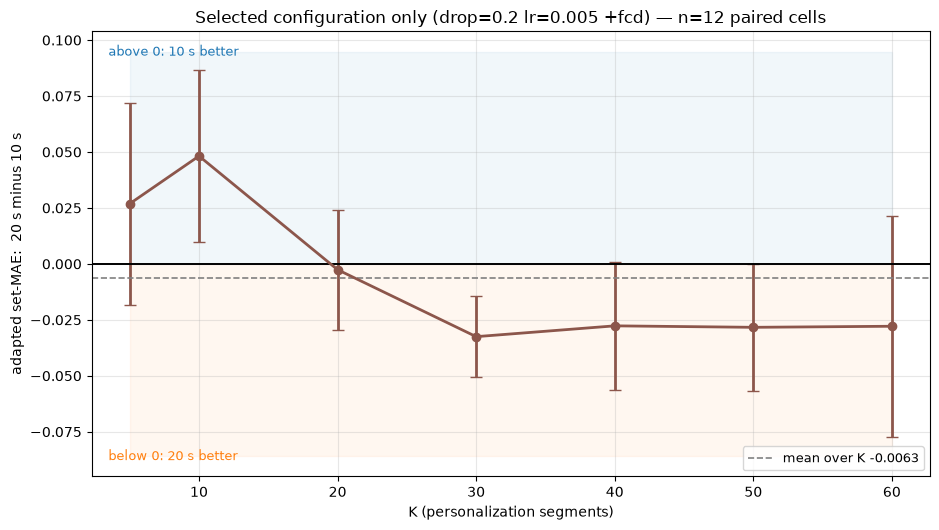

**Per-K, selected configuration (drop=0.2 lr=0.005 +fcd)**

,w10,w20,delta,se,t,winner
K,,,,,,
5,1.0602,1.0871,0.0269,0.0451,0.5965,10 s
10,1.0168,1.0650,0.0482,0.0385,1.2526,10 s
20,0.9640,0.9614,-0.0026,0.0267,-0.0969,20 s
30,0.8973,0.8648,-0.0325,0.0182,-1.7880,20 s
40,0.8206,0.7930,-0.0277,0.0287,-0.9629,20 s
50,0.7385,0.7101,-0.0283,0.0285,-0.9954,20 s
60,0.6651,0.6373,-0.0279,0.0495,-0.5631,20 s


mean of the per-K deltas          : -0.0063  -> 20 s better; 10 s wins 2/7 K values
ranking column (SMOOTHED, same epoch): -0.0085 +/- 0.0143 (t=-0.59)  -> 20 s better

|t| max across K = 1.79. At n=12 neither column resolves the
window at this configuration.


In [12]:
a, b = load_stage("corn_w10"), load_stage("corn_w20")
key = ["dropout", "lr", "embed_fcd", "fold", "seed"]
m = a.merge(b, on=key, suffixes=("_10", "_20"))
sel = blocked_table("corn_w10").iloc[0]
s = m[(m.dropout == sel.dropout) & (m.lr == sel.lr) & (m.embed_fcd == int(sel.fcd))]
lbl = f"drop={sel.dropout:g} lr={sel.lr:g}{' +fcd' if int(sel.fcd) else ''}"

mu, se = [], []
for k in ADAPT_KS:
    d = (s[f"adapt_mae_k{k}_20"] - s[f"adapt_mae_k{k}_10"]).dropna()
    mu.append(d.mean()); se.append(d.std(ddof=1) / np.sqrt(len(d)))
mu, se = np.array(mu), np.array(se)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.errorbar(ADAPT_KS, mu, yerr=se, marker="o", ms=6, lw=2, capsize=4, color="tab:brown")
ax.axhline(0, c="k", lw=1.4)
ax.axhline(mu.mean(), ls="--", c="0.5", lw=1.2, label=f"mean over K {mu.mean():+.4f}")
ax.fill_between([min(ADAPT_KS), max(ADAPT_KS)], 0, ax.get_ylim()[1],
                color="tab:blue", alpha=.06)
ax.fill_between([min(ADAPT_KS), max(ADAPT_KS)], ax.get_ylim()[0], 0,
                color="tab:orange", alpha=.06)
ax.text(.02, .97, "above 0: 10 s better", transform=ax.transAxes, va="top",
        fontsize=9, color="tab:blue")
ax.text(.02, .03, "below 0: 20 s better", transform=ax.transAxes, va="bottom",
        fontsize=9, color="tab:orange")
ax.set_xlabel("K (personalization segments)")
ax.set_ylabel("adapted set-MAE:  20 s minus 10 s")
ax.set_title(f"Selected configuration only ({lbl}) — n={len(s)} paired cells")
ax.grid(alpha=.3); ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

t = pd.DataFrame({"K": ADAPT_KS, "w10": [s[f"adapt_mae_k{k}_10"].mean() for k in ADAPT_KS],
                  "w20": [s[f"adapt_mae_k{k}_20"].mean() for k in ADAPT_KS],
                  "delta": mu, "se": se, "t": mu / se,
                  "winner": np.where(mu > 0, "10 s", "20 s")}).set_index("K")
display(Markdown(f"**Per-K, selected configuration ({lbl})**"))
display(t.round(4))

print(f"mean of the per-K deltas          : {mu.mean():+.4f}  -> "
      f"{'10 s' if mu.mean() > 0 else '20 s'} better; 10 s wins {(mu > 0).sum()}/7 K values")
d2 = (s.smoothed_best_adapt_mae_20 - s.smoothed_best_adapt_mae_10)
print(f"ranking column (SMOOTHED, same epoch): {d2.mean():+.4f} +/- "
      f"{d2.std(ddof=1)/np.sqrt(len(d2)):.4f} (t={d2.mean()/(d2.std(ddof=1)/np.sqrt(len(d2))):+.2f})"
      f"  -> {'10 s' if d2.mean() > 0 else '20 s'} better")
print()
print(f"|t| max across K = {np.abs(mu/se).max():.2f}. At n={len(s)} neither column resolves the")
print("window at this configuration.")

### G2. Optimal epoch per K, and what a single fixed E* costs


In [13]:
def per_k_optimal_epoch(name: str) -> pd.DataFrame:
    """One row per run, one column per K: the epoch minimising THAT K's own curve."""
    out, seen = [], set()
    for f in run_files(name):
        m = _TAG.match(f.stem[len("metrics_"):])
        if not m:
            continue
        c = pd.read_csv(f)
        r = {"dropout": float(m["drop"]), "lr": float(m["lr"]),
             "embed_fcd": int(bool(m["fcd"])), "fold": m["fold"].replace("-", "|"),
             "seed": int(m["seed"])}
        for k in ADAPT_KS:
            col = f"adapt_set_mae_k{k}"
            y = c[col].to_numpy(dtype=float) if col in c.columns else None
            fin = np.isfinite(y) if y is not None else np.array([False])
            if fin.sum() < 2:
                r[f"argmin_k{k}"] = np.nan; r[f"e1se_k{k}"] = np.nan; continue
            idx = np.flatnonzero(fin)
            ja, j1a, _ = reduce_curve(y[idx], MIN_SELECT_EPOCH)
            r[f"argmin_k{k}"] = int(c["epoch"].iloc[idx[ja]])
            r[f"e1se_k{k}"] = int(c["epoch"].iloc[idx[j1a]])
            r[f"curve_k{k}"] = smooth(y[idx], SMOOTH_WINDOW)
        out.append(r)
    return pd.DataFrame(out)


OPT = {nm: per_k_optimal_epoch(nm) for nm, _ in STAGES}

# ---- figure: optimal epoch vs K, selected configuration only
fig, ax = plt.subplots(figsize=(10, 5.6))
STY = {"corn_w10": ("tab:blue", "o"), "corn_w20": ("tab:orange", "s")}
for nm, _ in STAGES:
    sel = blocked_table(nm).iloc[0]
    d = sel_rows(OPT[nm], sel)
    if d.empty:
        continue
    col, mk = STY.get(nm, ("0.4", "o"))
    for pref, ls_, lab in (("argmin", "-", "argmin"), ("e1se", "--", "1-SE")):
        mu = [d[f"{pref}_k{k}"].mean() for k in ADAPT_KS]
        se = [d[f"{pref}_k{k}"].std(ddof=1) / np.sqrt(d[f"{pref}_k{k}"].notna().sum())
              for k in ADAPT_KS]
        ax.errorbar(ADAPT_KS, mu, yerr=se, marker=mk, ms=6, capsize=3, ls=ls_,
                    lw=2.2 if pref == "argmin" else 1.5, color=col,
                    alpha=1.0 if pref == "argmin" else .55, label=f"{nm} — {lab}")
ax.set_xlabel("K (personalization segments the driver will provide)")
ax.set_ylabel("epoch minimising that K's own curve")
ax.set_title("Optimal population training length vs labelling budget (selected config)")
ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- the decision table: what a single fixed E* costs at every K
CANDIDATE_ES = [3, 4, 5, 6, 7, 8, 9, 10, 12, 14]
for nm, _ in STAGES:
    sel = blocked_table(nm).iloc[0]
    d = sel_rows(OPT[nm], sel)
    if d.empty or f"curve_k{ADAPT_KS[0]}" not in d.columns:
        continue
    lbl = f"drop={sel.dropout:g} lr={sel.lr:g}{' +fcd' if int(sel.fcd) else ''}"
    curves = {k: list(d[f"curve_k{k}"]) for k in ADAPT_KS}
    # Best ACHIEVABLE per K: each K at its own optimum. The regret column below is
    # measured against this, so it reads as "what the single shared epoch costs".
    best = {k: np.mean([c.min() for c in curves[k]]) for k in ADAPT_KS}
    rows = []
    for E in CANDIDATE_ES:
        vals = {k: np.mean([c[min(E, len(c) - 1)] for c in curves[k]]) for k in ADAPT_KS}
        rows.append({"E*": E, **{f"K{k}": vals[k] for k in ADAPT_KS},
                     "mean": np.mean(list(vals.values())),
                     "regret": np.mean([vals[k] - best[k] for k in ADAPT_KS])})
    t = pd.DataFrame(rows).set_index("E*")
    display(Markdown(f"**{nm} ({lbl}) — smoothed set-MAE at a fixed E***"))
    display(t.round(3))
    b = int(t["mean"].idxmin())
    e1 = float(np.median([d[f"e1se_k{k}"].median() for k in ADAPT_KS]))
    print(f"  best fixed E* = {b} (mean {t.loc[b,'mean']:.3f}, regret {t.loc[b,'regret']:.3f})")
    print(f"  median per-K 1-SE epoch = {e1:.0f} — the conservative choice, since "
          f"run_lodo_population applies E* with NO early stopping")
    print(f"  best achievable per K: " + "  ".join(f"K{k}={best[k]:.3f}" for k in ADAPT_KS))
    print()

NameError: name 'run_files' is not defined